In [1]:
"""
CNN-LSTM Hybrid for SoC Prediction — FILE-LEVEL SPLITS (No Leakage)
=====================================================================
Split strategy:
  - Total File: N
  - 80% files → Training
  - 10% files → Validation
  - 10% files → Test
  (scaler is fit ONLY on training files)

Label strategies:
  1. Coulomb Counting (CC)
  2. Normalized Q_chg
"""

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

In [2]:
ROOT         = "./datasets/1_NCA"
SEQ_LEN      = 50
BATCH_SIZE   = 64
EPOCHS       = 10
LR           = 1e-3
HIDDEN_LSTM  = 128
CNN_CHANNELS = 64
DROPOUT      = 0.3
LABEL_MODE   = "both"        # "cc" | "norm_qchg" | "both"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

FEATURES     = ["Ecell/V", "<I>/mA", "Q discharge/mA.h", "Q charge/mA.h"]

# File-level split ratios  (must sum to 1.0)
VAL_RATIO    = 2 / 20        # 2 files for validation
TEST_RATIO   = 3 / 20        # 3 files for test

print(f"Device : {DEVICE}")
print(f"Labels : {LABEL_MODE}\n")

Device : cuda
Labels : both



In [3]:
# 1.  LOAD — keep files SEPARATE as a list
def load_all_separate(root: str):
    """
    Returns a list of (filename, DataFrame) tuples.
    Each DataFrame is one battery file — kept separate on purpose.
    """
    records = []
    for path in sorted(glob.glob(os.path.join(root, "*.csv"))):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        df["source_file"] = os.path.basename(path)
        # charge-only filter
        df = df[df["<I>/mA"] > 0].copy()
        df = df.dropna(subset=FEATURES + ["cycle number"])
        if len(df) > SEQ_LEN:          # skip files too short
            records.append((os.path.basename(path), df))
    print(f"Loaded {len(records)} usable files")
    return records

all_files = load_all_separate(ROOT)     # list of (name, df)
n_files   = len(all_files)

Loaded 20 usable files


In [4]:
# 2.  FILE-LEVEL SPLIT
# Shuffle file list with a fixed seed so the split is reproducible
rng = np.random.default_rng(42)
indices = rng.permutation(n_files)

n_test  = max(1, round(n_files * TEST_RATIO))
n_val   = max(1, round(n_files * VAL_RATIO))
n_train = n_files - n_test - n_val

test_idx  = indices[:n_test]
val_idx   = indices[n_test : n_test + n_val]
train_idx = indices[n_test + n_val :]

train_files = [all_files[i] for i in train_idx]
val_files   = [all_files[i] for i in val_idx]
test_files  = [all_files[i] for i in test_idx]

print(f"\nFile-level split:")
print(f"  Train : {len(train_files)} files → {[f for f,_ in train_files[:5]]} ...")
print(f"  Val   : {len(val_files)}  files → {[f for f,_ in val_files]}")
print(f"  Test  : {len(test_files)}  files → {[f for f,_ in test_files]}")


File-level split:
  Train : 15 files → ['CY25-05_1-#9.csv', 'CY25-05_1-#5.csv', 'CY25-1_1-#9.csv', 'CY25-05_1-#2.csv', 'CY25-05_1-#1.csv'] ...
  Val   : 2  files → ['CY25-05_1-#6.csv', 'CY25-1_1-#2.csv']
  Test  : 3  files → ['CY25-1_1-#5.csv', 'CY25-05_1-#8.csv', 'CY25-1_1-#4.csv']


In [5]:
# 3.  LABEL GENERATION  (applied per-file, per-cycle)
def coulomb_counting_soc(group: pd.DataFrame) -> pd.Series:
    t      = group["time/s"].values
    I      = group["<I>/mA"].values
    dt     = np.diff(t, prepend=t[0])
    Q_cum  = np.cumsum(I * dt / 3600.0)
    Q_tot  = Q_cum[-1]
    if Q_tot <= 0:
        return pd.Series(np.zeros(len(group)), index=group.index)
    return pd.Series(np.clip(Q_cum / Q_tot, 0.0, 1.0), index=group.index)


def norm_qchg_soc(group: pd.DataFrame) -> pd.Series:
    q     = group["Q charge/mA.h"].values
    q_max = q.max()
    if q_max <= 0:
        return pd.Series(np.zeros(len(group)), index=group.index)
    return pd.Series(np.clip(q / q_max, 0.0, 1.0), index=group.index)


def add_labels(file_list):
    """Add SoC labels to every file's DataFrame."""
    labeled = []
    for fname, df in file_list:
        grp = ["source_file", "cycle number"]
        df["SoC_CC"]        = df.groupby(grp, group_keys=False).apply(coulomb_counting_soc)
        df["SoC_norm_Qchg"] = df.groupby(grp, group_keys=False).apply(norm_qchg_soc)
        labeled.append((fname, df))
    return labeled

print("\nGenerating labels …")
train_files = add_labels(train_files)
val_files   = add_labels(val_files)
test_files  = add_labels(test_files)


Generating labels …


In [6]:
# 4.  FEATURE SCALER — fit ONLY on train files
train_df_all = pd.concat([df for _, df in train_files], ignore_index=True)

feat_scaler = MinMaxScaler()
feat_scaler.fit(train_df_all[FEATURES])   # ← sees ONLY training data

def scale_files(file_list, scaler):
    scaled = []
    for fname, df in file_list:
        df = df.copy()
        df[FEATURES] = scaler.transform(df[FEATURES])
        scaled.append((fname, df))
    return scaled

train_files = scale_files(train_files, feat_scaler)
val_files   = scale_files(val_files,   feat_scaler)
test_files  = scale_files(test_files,  feat_scaler)

print("Scaler fit on training files only ✓")

Scaler fit on training files only ✓


In [7]:
# 5.  SLIDING-WINDOW BUILDER
def build_sequences(file_list, seq_len: int, label_col: str):
    """
    Build sequences from a list of (fname, df).
    Windows never cross cycle or file boundaries.
    """
    X_list, y_list = [], []
    for fname, df in file_list:
        for _, grp in df.groupby(["source_file", "cycle number"]):
            grp   = grp.reset_index(drop=True)
            feats = grp[FEATURES].values
            labs  = grp[label_col].values
            T     = len(grp)
            if T <= seq_len:
                continue
            for i in range(T - seq_len):
                X_list.append(feats[i : i + seq_len])
                y_list.append(labs[i + seq_len])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

In [ ]:
# 6.  DATASET & DATALOADER
class BatteryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# 7.  CNN-LSTM MODEL
class CNN_LSTM(nn.Module):
    def __init__(self, n_features, seq_len,
                 cnn_channels=64, hidden_lstm=128, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Dropout(dropout), #512 -> 512 -> hid:256 lstm -> head 256 -> 256/128 -> 1 
            # long kernel size 5/7, padding, stride fixation.
        )
        self.lstm = nn.LSTM(
            input_size=cnn_channels, hidden_size=hidden_lstm,
            num_layers=2, batch_first=True, dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_lstm, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        out = self.cnn(x.permute(0, 2, 1))          # (B,F,T) → (B,C,T)
        out, _ = self.lstm(out.permute(0, 2, 1))     # (B,T,C) → (B,T,H)
        return self.head(out[:, -1, :])

In [9]:
# 8.  TRAIN / EVAL
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * len(X_b)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total, preds, trues = 0.0, [], []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        p = model(X_b)
        total += criterion(p, y_b).item() * len(X_b)
        preds.append(p.cpu().numpy())
        trues.append(y_b.cpu().numpy())
    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()
    return total / len(loader.dataset), preds, trues


def run_experiment(label_col: str, label_name: str):
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT : {label_name}")
    print(f"{'='*60}")

    print("  Building sequences …")
    X_tr, y_tr = build_sequences(train_files, SEQ_LEN, label_col)
    X_va, y_va = build_sequences(val_files,   SEQ_LEN, label_col)
    X_te, y_te = build_sequences(test_files,  SEQ_LEN, label_col)

    print(f"  Sequences → Train: {len(X_tr):,} | Val: {len(X_va):,} | Test: {len(X_te):,}")

    tr_loader = DataLoader(BatteryDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(BatteryDataset(X_va, y_va), batch_size=BATCH_SIZE)
    te_loader = DataLoader(BatteryDataset(X_te, y_te), batch_size=BATCH_SIZE)

    model     = CNN_LSTM(len(FEATURES), SEQ_LEN, CNN_CHANNELS, HIDDEN_LSTM, DROPOUT).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5,
                                                            factor=0.5, verbose=False)

    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

    best_val, best_state = float("inf"), None
    history = {"train": [], "val": []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, tr_loader, optimizer, criterion)
        va_loss, _, _ = evaluate(model, va_loader, criterion)
        scheduler.step(va_loss)
        history["train"].append(tr_loss)
        history["val"].append(va_loss)
        if va_loss < best_val:
            best_val   = va_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS}  │  train={tr_loss:.5f}  │  val={va_loss:.5f}")

    model.load_state_dict(best_state)
    _, preds, trues = evaluate(model, te_loader, criterion)

    metrics = {
        "MAE" : mean_absolute_error(trues, preds),
        "RMSE": np.sqrt(mean_squared_error(trues, preds)),
        "R2"  : r2_score(trues, preds),
    }
    print(f"\n  Test  →  MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}  R²={metrics['R2']:.4f}")

    safe = label_name.replace(" ", "_").replace("/", "_")
    torch.save({"state": best_state, "label": label_name,
                "seq_len": SEQ_LEN, "features": FEATURES,
                "scaler": feat_scaler}, f"cnn_lstm_{safe}.pt")

    return history, preds, trues, metrics

In [10]:
# 9.  RUN
results = {}
if LABEL_MODE in ("cc",       "both"):
    results["CC"] = run_experiment("SoC_CC",        "Coulomb_Counting")
if LABEL_MODE in ("norm_qchg","both"):
    results["NQ"] = run_experiment("SoC_norm_Qchg", "Normalized_Q_chg")


  EXPERIMENT : Coulomb_Counting
  Building sequences …
  Sequences → Train: 888,953 | Val: 110,327 | Test: 94,807
  Parameters: 253,185
  Epoch   1/10  │  train=0.00081  │  val=0.00013
  Epoch  10/10  │  train=0.00065  │  val=0.00020

  Test  →  MAE=0.0079  RMSE=0.0108  R²=0.9986

  EXPERIMENT : Normalized_Q_chg
  Building sequences …
  Sequences → Train: 888,953 | Val: 110,327 | Test: 94,807
  Parameters: 253,185
  Epoch   1/10  │  train=0.00085  │  val=0.00018
  Epoch  10/10  │  train=0.00067  │  val=0.00041

  Test  →  MAE=0.0084  RMSE=0.0114  R²=0.9985



Plot saved → cnn_lstm_soc_filelevel_results.png


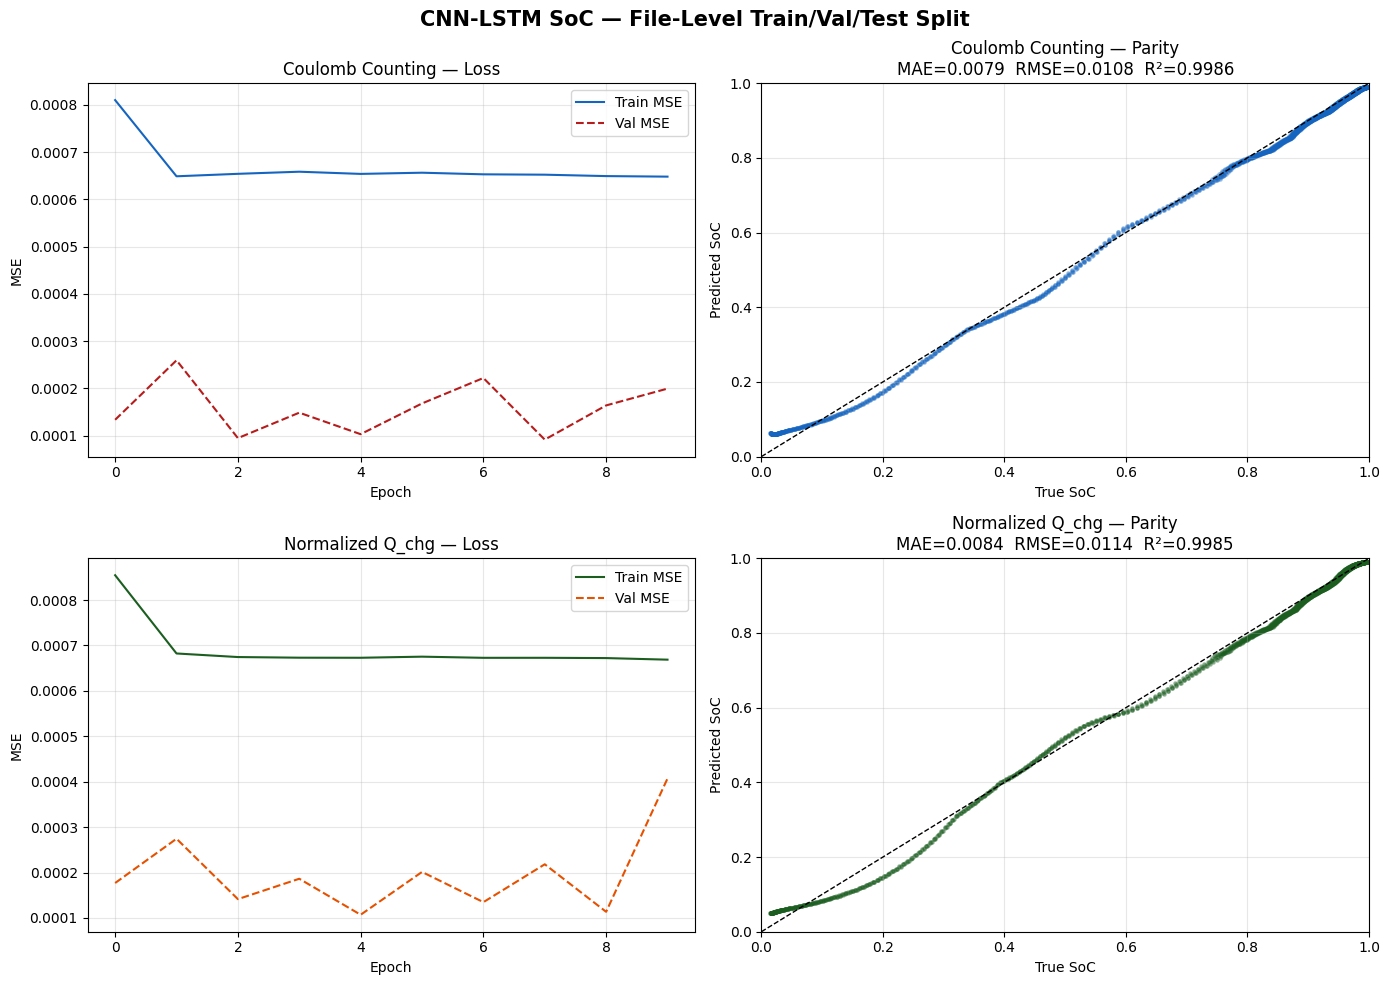

In [11]:
# 10.  PLOTS
labels_map = {"CC": "Coulomb Counting", "NQ": "Normalized Q_chg"}
colors_map = {"CC": ("#1565C0","#B71C1C"), "NQ": ("#1B5E20","#E65100")}

n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(14, 5*n), squeeze=False)
fig.suptitle("CNN-LSTM SoC — File-Level Train/Val/Test Split", fontsize=15, fontweight="bold")

for row, (key, (hist, preds, trues, met)) in enumerate(results.items()):
    c_tr, c_va = colors_map[key]
    title      = labels_map[key]

    # loss curve
    ax = axes[row][0]
    ax.plot(hist["train"], color=c_tr, lw=1.5, label="Train MSE")
    ax.plot(hist["val"],   color=c_va, lw=1.5, linestyle="--", label="Val MSE")
    ax.set_title(f"{title} — Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
    ax.legend(); ax.grid(alpha=0.3)

    # parity plot
    ax = axes[row][1]
    n_pts = min(2000, len(trues))
    ax.scatter(trues[:n_pts], preds[:n_pts], alpha=0.3, s=6, color=c_tr)
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f"{title} — Parity\nMAE={met['MAE']:.4f}  RMSE={met['RMSE']:.4f}  R²={met['R2']:.4f}")
    ax.set_xlabel("True SoC"); ax.set_ylabel("Predicted SoC")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_lstm_soc_filelevel_results.png", dpi=150)
print("\nPlot saved → cnn_lstm_soc_filelevel_results.png")
plt.show()

In [12]:
# 11.  SUMMARY
print("\n" + "─"*48)
print(f"{'Split':<12} {'Train files':>11} {'Val files':>9} {'Test files':>10}")
print("─"*48)
print(f"{'Count':<12} {len(train_files):>11} {len(val_files):>9} {len(test_files):>10}")
print("─"*48)
print(f"\n{'Method':<22} {'MAE':>7} {'RMSE':>8} {'R²':>7}")
print("─"*48)
for key, (_, _, _, m) in results.items():
    print(f"{labels_map[key]:<22} {m['MAE']:>7.4f} {m['RMSE']:>8.4f} {m['R2']:>7.4f}")
print("─"*48)


────────────────────────────────────────────────
Split        Train files Val files Test files
────────────────────────────────────────────────
Count                 15         2          3
────────────────────────────────────────────────

Method                     MAE     RMSE      R²
────────────────────────────────────────────────
Coulomb Counting        0.0079   0.0108  0.9986
Normalized Q_chg        0.0084   0.0114  0.9985
────────────────────────────────────────────────
